The overall goal of this project is to find the set of controls (accelerator position, brake pressed, steering) for an optimised speed input (speed, position).
- Steering data is unavailable, so is currently out of scope.
- FSGP data from 2024 July, potentially over like 2-3 days (16-18 July)

current ideas for a workflow:

- using a RNN for a state to control model.
- we are mapping state inputs (velocity, position) to control (accel, brake pressed, steering)
- a question is - position as a dependent of speed, but i feel like it makes sense to use it anyways because otherwise the model wouldn't be able to pinpoint that particular part of the track with corresponding cornering/acceleration changes.


other references:
https://docs.google.com/spreadsheets/d/1yjyuKODt6wtIB31OLfhpwe0kKQ4CeoXJ/edit?gid=159364596#gid=159364596
- this document has lap timings
- i also used Miguel's monday updates to find which laps were ignored/had issues
- for now the RNN does not need to distinguish between laps, but  i wonder if that could be a possible input

In [ ]:
#other references :


In [2]:
#necessary imports
import sklearn as sk

In [3]:
# query data from influx. looking at timestamps of 2024 FSGP: 14 - 18 overall, but for smaller data response lets try 14 -16

from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os
import pytz
from datetime import datetime, time, date

#each 5 seconds
utc_offset_h = 7
start_utc = time(0+utc_offset_h, 00, 00)  #querying i svancouver time, influxdb gives utc
stop_utc = time(16+utc_offset_h, 45, 00)
date_start = date(2024, 7, 16)
date_stop = date(2024, 7, 18)

vancouver = pytz.timezone("America/Vancouver")

start_local = vancouver.localize(datetime.combine(date_start, start_utc))
stop_local = vancouver.localize(datetime.combine(date_stop, stop_utc))

start_time = start_local.astimezone(pytz.utc)
stop_time = stop_local.astimezone(pytz.utc)

client = query.DBClient()
mech_brake_pressed: TimeSeries = client.query_time_series(start_time, stop_time, field="MechBrakePressed")
accel_position: TimeSeries =   client.query_time_series(start_time, stop_time, field="AcceleratorPosition")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "VehicleVelocity")



In [1]:
# speed is most likely in m/s

In [4]:

# save collected data

out_dir = os.path.join("../../array_temp", "data", "control_state_fsgp_2024")
os.makedirs(out_dir, exist_ok=True)

brake_path = os.path.join(out_dir, "brake_pressed.bin")
accel_path = os.path.join(out_dir, "acceleration.bin")
speed_path = os.path.join(out_dir, "speed_kph.bin")

filepaths = [brake_path, accel_path, speed_path]
datasets = [mech_brake_pressed, accel_position, speed_kph]

for filepath, data in zip(filepaths, datasets):
    with open(filepath, "wb") as f:
        dill.dump(data, f)


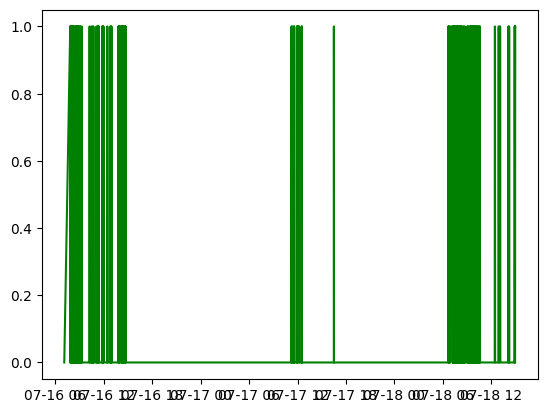

In [5]:
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")

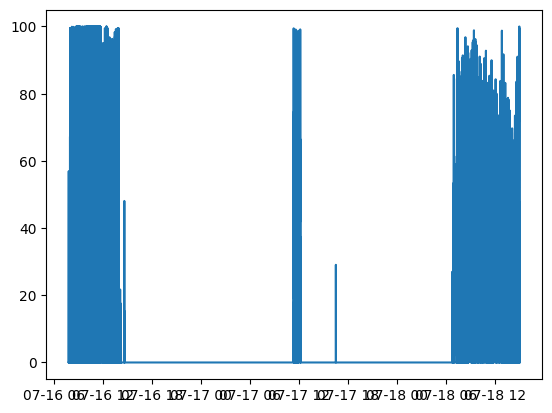

In [6]:
plt.plot(accel_position.datetime_x_axis, accel_position, label = "Accelerator Position")


In [7]:
# accel position and brake pressed are in inconsistent units, so i'll probbaly change them to a 0-1 range.

#using min, max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_accel_position = scaler.fit_transform(accel_position.reshape(-1, 1))




Text(0.5, 1.0, 'speed kph')

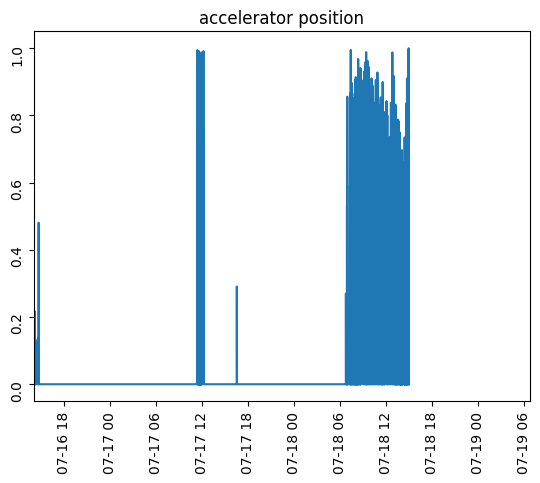

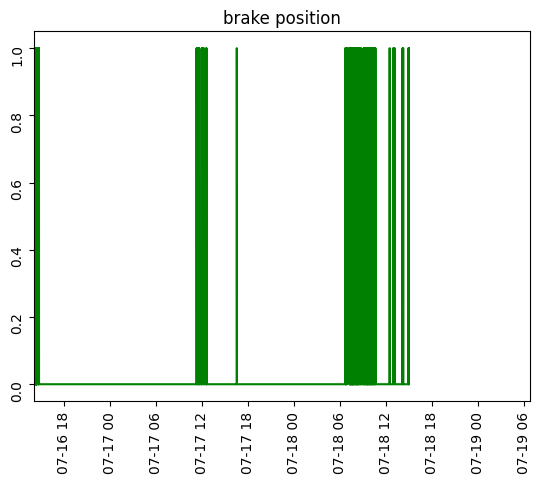

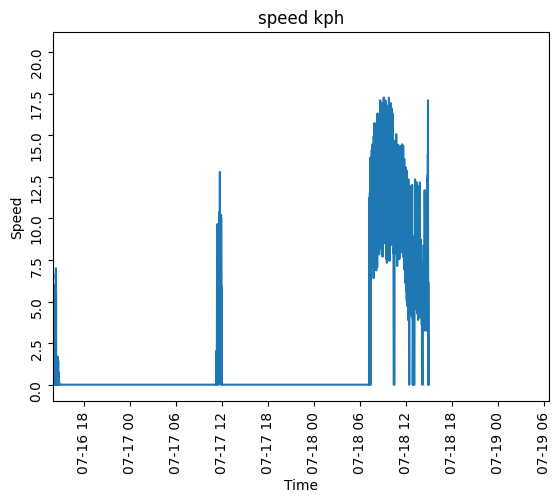

In [9]:
plt.figure(1)
plt.plot(accel_position.datetime_x_axis, scaled_accel_position, label = "Accelerator Position")
plt.xlim(start_time, stop_time)
plt.title("accelerator position")
plt.tick_params(rotation = 90)

plt.figure(2)
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")
plt.title("brake position")
plt.tick_params(rotation = 90)
plt.xlim(start_time, stop_time)
plt.figure(3)
# position is defined as a percentage

plt.plot(speed_kph.datetime_x_axis, speed_kph, label = "Speed KPH")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.tick_params(rotation = 90)
plt.xlim(start_time, stop_time)
plt.title("speed kph")


In [10]:
# why does brake pressed look more continous then acceleartor - accelerator seems like it is either 100% or none
# a good place where this lines up is

Text(0.5, 1.0, 'speed kph')

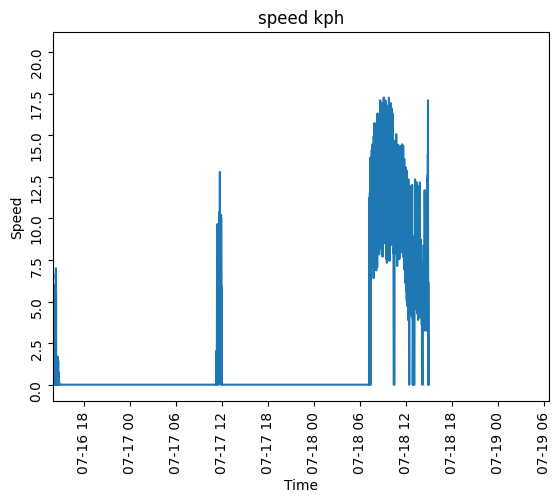

In [11]:
plt.plot(speed_kph.datetime_x_axis, speed_kph, label = "Speed KPH")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.tick_params(rotation = 90)
plt.xlim(start_time, stop_time)
plt.title("speed kph")

# what is up with the whack units



In [12]:
#clearly speed units are whack. from looking at lap data, i see that out average speed was around 16 miles per hour. so i think due to hwo influx registers small numbers in different units, we are probably looking at

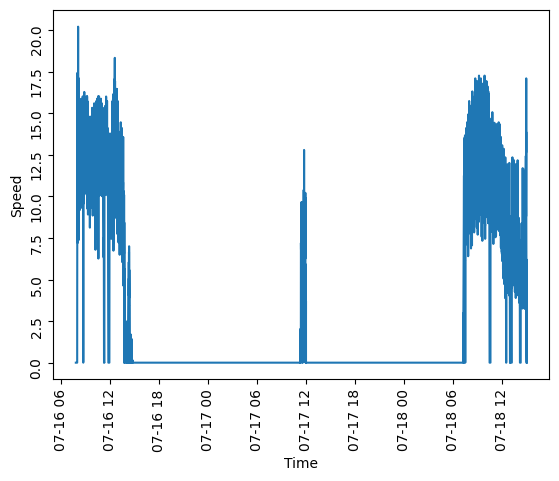

In [13]:
# position is defined as a percentage

plt.plot(speed_kph.datetime_x_axis, speed_kph, label = "Speed KPH")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.tick_params(rotation = 90)

C:\Users\sanar\AppData\Local\Temp\ipykernel_27256\1203527545.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc = "upper left")


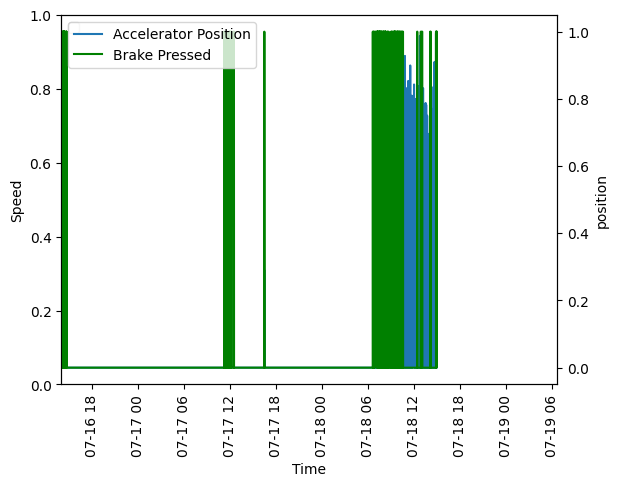

In [14]:
#plot relevant data

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(accel_position.datetime_x_axis, scaled_accel_position, label = "Accelerator Position")
plt.xlim(start_time, stop_time)
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")
plt.xlim(start_time, stop_time)
#ax1.plot(speed_kph.datetime_x_axis, speed_kph, color = 'red', label = "Speed KPH")


ax1.set_xlabel("Time")
ax1.set_ylabel("Speed")
ax_twin.set_ylabel("position")

ax1.tick_params("x", rotation  = 90)


plt.legend(loc = "upper left")
ax1.legend(loc = "upper left")
plt.show()

In [15]:
# in order to get position data, look up miguel's work for localization of fsgp data


# this project is essentially constrained in one lap


#from miguel's code, we find the number of laps done on one day, so let us

localisation code is primarily for day1 and day3 of fsgp.
- integrate the velocity curve up to a point and then manual mapping from distance covered to found coordinates.
- labs before and after we pitted will have nan values
- lap7 day1 - might have diverging velocities
- he dip happens after lap 28 and lap 32 which is when we pitted.
- used MDI vehicle velocity
-

In [18]:
from data_tools import lap_tools
from physics.environment.gis.gis import GIS
from physics.environment.gis.gis import calculate_path_distances

# Defining dictionary "route_data"

route_data = {
    "path" : np.array(coords),
    "elevations" : np.zeros(len(coords)),
    "time_zones" : np.zeros(len(coords)),
    "num_unique_coords" : (len(coords) - 1) }

# Creating GIS object

starting_coords = [37.00107373, -86.36854755]

gis = GIS(route_data, starting_coords, current_coord = starting_coords)

lap_length = np.cumsum(calculate_path_distances(gis.path[:gis.num_unique_coords]))[-1] # TOTAL LAP LENGTH

NameError: name 'coords' is not defined

In [32]:
#preprocessing - convert everything to pandas dataframes.


df_mech_brake_pressed = pd.DataFrame(mech_brake_pressed)
df_accel_position = pd.DataFrame(scaled_accel_position)
df_speed_kph = pd.DataFrame(speed_kph)




In [34]:
df_speed_kph.head(100)

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
95,0.0
96,0.0
97,0.0
98,0.0


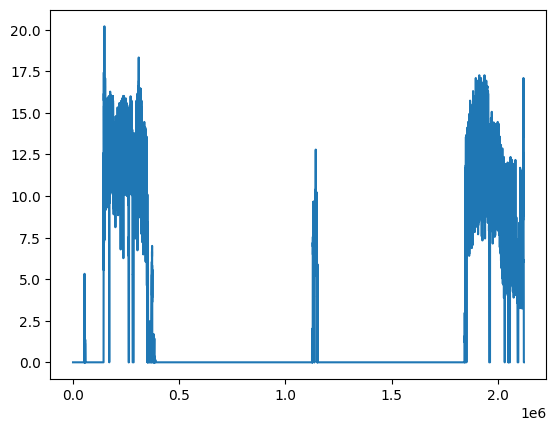

In [35]:
plt.plot(df_speed_kph)

In [40]:
# combine all dfs and resample, then feed to scaler.
# states = velocity, position
# control = mbrake pressed, accelerator position
def combine_dfs(telemetry_names, index_common, all_dfs):
        combined_df = pd.DataFrame(index=index_common)

        for name, df in zip(telemetry_names, all_dfs):
            #df_interp = self.resample(df, index_common)
            combined_df[name] = df

        return combined_df


In [42]:
all_dfs = [df_mech_brake_pressed, df_accel_position, df_speed_kph]
combined_df = combine_dfs(["mech_brake_pressed", "accel_position", "speed_kph"], df_mech_brake_pressed.index, all_dfs)


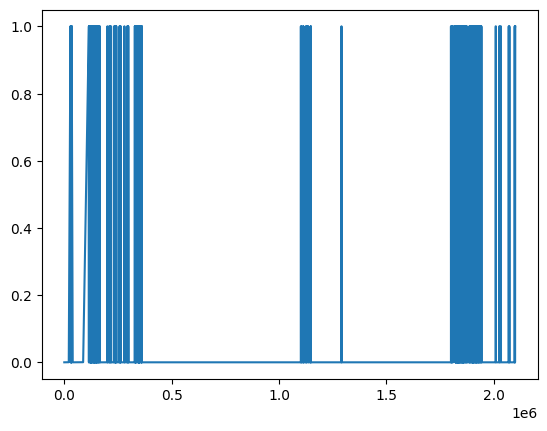

In [43]:
plt.plot(combined_df["mech_brake_pressed"])

In [ ]:
# i dont really think there is much of a need to resample right now, because on querying from influx they will all be at the same frequency.
# preprocessing pipeline: dataset - rescaling - sequences - tensors - RNN

In [17]:
# testing training split - 70 - 30

from sklearn.preprocessing import StandardScaler


def

# Choose columns to scale (all states + controls)
cols_to_scale = state + control

# Fit scaler on the training portion only
train_len = int(0.8 * len(final_df_car13))
df_train_raw = final_df_car13.iloc[:train_len].reset_index(drop=True)
df_test_raw  = final_df_car13.iloc[train_len:].reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(df_train_raw[cols_to_scale])  # fit only on train

# Transform both train and test
df_train = df_train_raw.copy()
df_train[cols_to_scale] = scaler.transform(df_train_raw[cols_to_scale])

df_test = df_test_raw.copy()
df_test[cols_to_scale] = scaler.transform(df_test_raw[cols_to_scale])


SyntaxError: invalid syntax (1177843209.py, line 6)